# 04 Correlation and Granger Causality Analysis

In [3]:
# notebook objective - 
# Identify which sensors contain predictive information for 03TIC_1009.PV and determine useful lag ranges for feature engineering.


In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import grangercausalitytests

import warnings
warnings.filterwarnings("ignore")

In [5]:
DATA_PATH = "../data/interim/data_sorted.parquet"

df = pd.read_parquet(DATA_PATH)

print(df.shape)

df.head()

(1737585, 14)


,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,03TI_1081.PV,03TI_1102.PV,03TI_1108.PV,03TI_1404.PV
0,2022-01-03 22:45:00,6.645525,216.82233,30.962135,52.072630,25.146055,35.456966,4.624359,45.199110,42.732693,-36.141970,NaN,31.587097,36.090870
1,2022-01-03 22:46:00,6.682778,210.55800,32.483753,54.947033,25.226107,35.332653,4.643196,45.199110,42.401283,-36.198616,10.000004,31.564457,36.251778
2,2022-01-03 22:47:00,6.713386,212.94440,31.975134,55.953170,25.315577,35.016205,4.605526,45.199110,42.600132,-36.283580,9.962143,31.587097,36.280174
3,2022-01-03 22:48:00,6.706837,213.07224,32.305733,55.358322,25.400337,35.389156,4.793884,45.199110,42.495970,-36.297745,9.858025,31.598423,36.176056
4,2022-01-03 22:49:00,6.670256,214.64897,31.852217,56.762740,25.452137,35.287450,4.793884,45.227604,42.401283,-36.241100,9.734978,31.598423,36.251778


In [6]:
TARGET = "03TIC_1009.PV"

FEATURES = [
    col
    for col in df.columns
    if col not in ["TimeStamp", TARGET]
]

print(len(FEATURES))
FEATURES

12


['02FI_1000.PV',
 '03FIC_1085.PV',
 '03FI_3418.PV',
 '03LIC_1094.PV',
 '03PIC_1104.PV',
 '03TIC_1092.PV',
 '03TI_1002.PV',
 '03TI_1005.PV',
 '03TI_1081.PV',
 '03TI_1102.PV',
 '03TI_1108.PV',
 '03TI_1404.PV']

In [7]:
# pearson correlation

pearson_corr = (
    df
    .drop(columns=["TimeStamp"])
    .corr(method="pearson")
)

pearson_corr

,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,03TI_1081.PV,03TI_1102.PV,03TI_1108.PV,03TI_1404.PV
02FI_1000.PV,1.000000,0.282019,-0.099747,-0.026262,-0.618787,0.205101,-0.042835,-0.019065,-0.032707,0.380877,-0.016356,0.180949,-0.088696
03FIC_1085.PV,0.282019,1.000000,-0.266207,0.078302,-0.316494,0.485693,0.186976,0.343084,0.374311,0.453452,0.338281,0.472684,0.155185
03FI_3418.PV,-0.099747,-0.266207,1.000000,0.194684,0.225303,-0.241136,0.232055,-0.171499,-0.203436,-0.171431,0.021311,-0.192388,-0.148052
03LIC_1094.PV,-0.026262,0.078302,0.194684,1.000000,0.013175,0.095618,0.138683,-0.004954,-0.014338,-0.032740,0.120319,0.084346,-0.055741
03PIC_1104.PV,-0.618787,-0.316494,0.225303,0.013175,1.000000,-0.238755,-0.061152,-0.134683,-0.142930,-0.420504,-0.050500,-0.206018,-0.119222
03TIC_1009.PV,0.205101,0.485693,-0.241136,0.095618,-0.238755,1.000000,0.306562,0.530210,0.603386,0.568669,0.784599,0.931848,0.152824
03TIC_1092.PV,-0.042835,0.186976,0.232055,0.138683,-0.061152,0.306562,1.000000,0.338914,0.353568,0.401191,0.629609,0.359190,0.293365
03TI_1002.PV,-0.019065,0.343084,-0.171499,-0.004954,-0.134683,0.530210,0.338914,1.000000,0.965629,0.463925,0.442186,0.465176,0.848115
03TI_1005.PV,-0.032707,0.374311,-0.203436,-0.014338,-0.142930,0.603386,0.353568,0.965629,1.000000,0.523299,0.490300,0.532136,0.844151
03TI_1081.PV,0.380877,0.453452,-0.171431,-0.032740,-0.420504,0.568669,0.401191,0.463925,0.523299,1.000000,0.424897,0.552434,0.345923


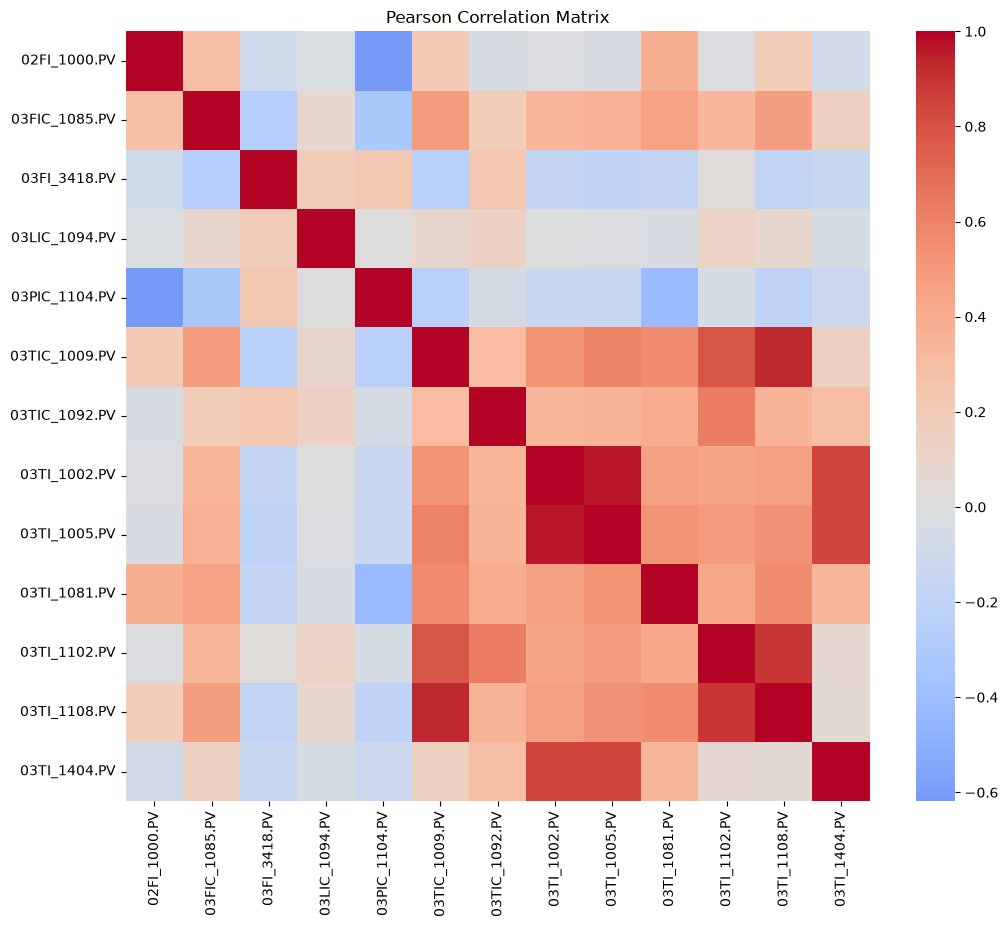

In [8]:
# pearson heatmap

plt.figure(figsize=(12,10))

sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Pearson Correlation Matrix"
)

plt.show()

In [9]:
# spearman correlation

spearman_corr = (
    df
    .drop(columns=["TimeStamp"])
    .corr(method="spearman")
)

spearman_corr

,02FI_1000.PV,03FIC_1085.PV,03FI_3418.PV,03LIC_1094.PV,03PIC_1104.PV,03TIC_1009.PV,03TIC_1092.PV,03TI_1002.PV,03TI_1005.PV,03TI_1081.PV,03TI_1102.PV,03TI_1108.PV,03TI_1404.PV
02FI_1000.PV,1.000000,0.308172,-0.146963,-0.023081,-0.347176,0.169961,-0.188493,-0.022028,-0.033184,0.398710,-0.123380,0.151571,-0.089306
03FIC_1085.PV,0.308172,1.000000,-0.361184,0.055747,-0.358862,0.506995,0.181179,0.360094,0.386050,0.552628,0.267451,0.476151,0.205180
03FI_3418.PV,-0.146963,-0.361184,1.000000,0.305573,0.294078,-0.255470,0.229037,-0.207932,-0.233030,-0.181872,0.037815,-0.229253,-0.167288
03LIC_1094.PV,-0.023081,0.055747,0.305573,1.000000,-0.031240,0.103431,0.169488,0.001952,-0.012589,0.034172,0.127020,0.091820,-0.027769
03PIC_1104.PV,-0.347176,-0.358862,0.294078,-0.031240,1.000000,-0.190367,-0.055409,-0.162734,-0.167296,-0.420013,0.009892,-0.153860,-0.178757
03TIC_1009.PV,0.169961,0.506995,-0.255470,0.103431,-0.190367,1.000000,0.170915,0.454308,0.515922,0.439726,0.649494,0.929365,0.138782
03TIC_1092.PV,-0.188493,0.181179,0.229037,0.169488,-0.055409,0.170915,1.000000,0.309452,0.304949,0.257085,0.646004,0.248856,0.304499
03TI_1002.PV,-0.022028,0.360094,-0.207932,0.001952,-0.162734,0.454308,0.309452,1.000000,0.964021,0.365423,0.350441,0.345053,0.859948
03TI_1005.PV,-0.033184,0.386050,-0.233030,-0.012589,-0.167296,0.515922,0.304949,0.964021,1.000000,0.410854,0.371211,0.395204,0.867497
03TI_1081.PV,0.398710,0.552628,-0.181872,0.034172,-0.420013,0.439726,0.257085,0.365423,0.410854,1.000000,0.196587,0.399947,0.295430


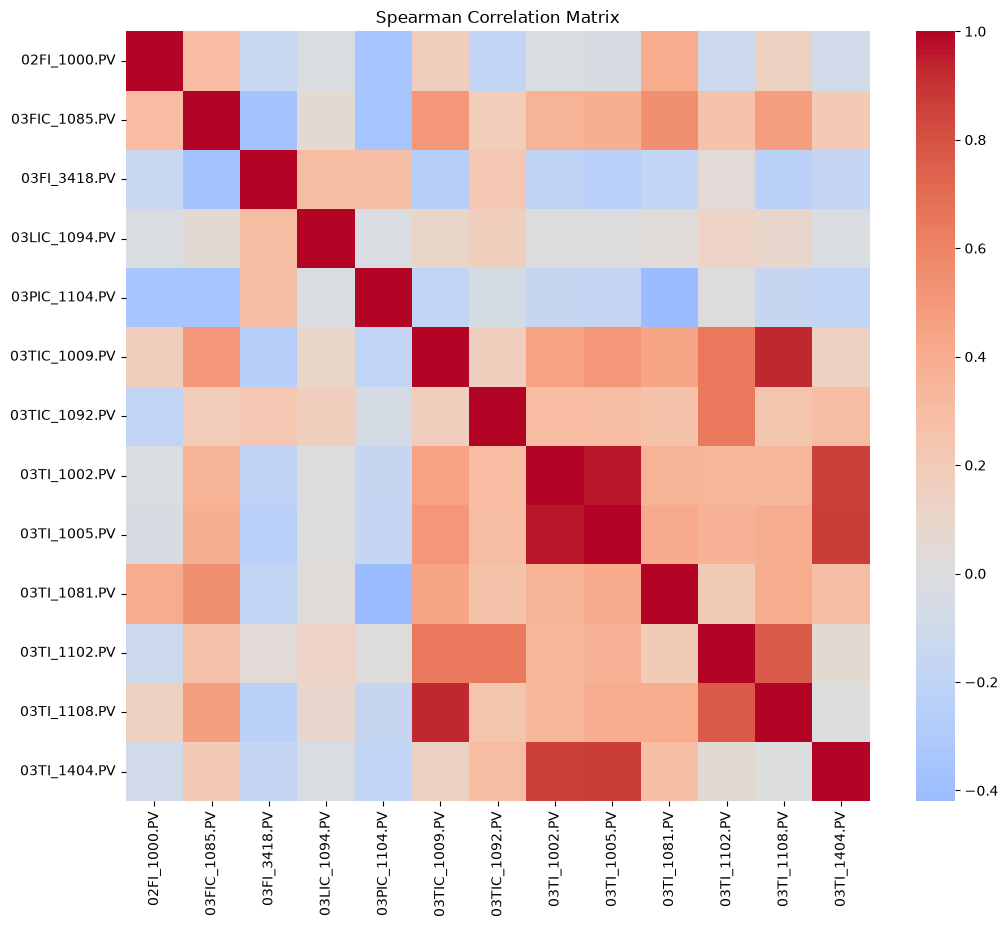

In [10]:
# spearman heatmap

plt.figure(figsize=(12,10))

sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Spearman Correlation Matrix"
)

plt.show()

In [11]:
# target correlation ranking

target_corr = (
    pearson_corr[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(
        ascending=False
    )
)

target_corr

target_corr_df = (
    target_corr
    .reset_index()
)

target_corr_df.columns = [
    "Feature",
    "Abs_Pearson_Corr"
]

target_corr_df

,Feature,Abs_Pearson_Corr
0,03TI_1108.PV,0.931848
1,03TI_1102.PV,0.784599
2,03TI_1005.PV,0.603386
3,03TI_1081.PV,0.568669
4,03TI_1002.PV,0.530210
5,03FIC_1085.PV,0.485693
6,03TIC_1092.PV,0.306562
7,03FI_3418.PV,0.241136
8,03PIC_1104.PV,0.238755
9,02FI_1000.PV,0.205101


In [12]:
target_corr_df.to_csv(
    "../outputs/reports/target_correlations.csv",
    index=False
)

In [13]:
#GRANGER ANALYSIS
#REDUCE DATASET
granger_df = (
    df
    .set_index("TimeStamp")
    .resample("15min")
    .mean()
    .dropna()
)

granger_df = (
    granger_df
    .tail(10000)
)

print(granger_df.shape)

(10000, 13)


In [17]:
MAX_LAG = 12

In [18]:
def run_granger(
    df,
    feature,
    target,
    max_lag=12
):

    data = df[
        [target, feature]
    ].dropna()

    results = grangercausalitytests(
        data,
        maxlag=max_lag,
        verbose=False
    )

    pvals = []

    for lag in range(
        1,
        max_lag + 1
    ):
        pvals.append(
            results[lag][0]
            ["ssr_ftest"][1]
        )

    return (
        np.argmin(pvals) + 1,
        np.min(pvals)
    )

In [19]:
TARGET = "03TIC_1009.PV"

TOP_FEATURES = [
    "03TI_1108.PV",
    "03TI_1102.PV",
    "03TI_1005.PV",
    "03TI_1081.PV",
    "03TI_1002.PV",
    "03FIC_1085.PV"
]

In [20]:
granger_results = []

for feature in TOP_FEATURES:

    print(
        f"Running {feature}"
    )

    lag, pval = run_granger(
        granger_df,
        feature,
        TARGET,
        max_lag=12
    )

    granger_results.append(
        {
            "Feature": feature,
            "Best_Lag": lag,
            "Min_P_Value": pval
        }
    )
    

Running 03TI_1108.PV
Running 03TI_1102.PV
Running 03TI_1005.PV
Running 03TI_1081.PV
Running 03TI_1002.PV
Running 03FIC_1085.PV


In [21]:
granger_results = (
    pd.DataFrame(
        granger_results
    )
    .sort_values(
        "Min_P_Value"
    )
)

granger_results

,Feature,Best_Lag,Min_P_Value
0,03TI_1108.PV,10,0.000000e+00
2,03TI_1005.PV,2,0.000000e+00
3,03TI_1081.PV,2,0.000000e+00
4,03TI_1002.PV,2,0.000000e+00
5,03FIC_1085.PV,2,0.000000e+00
1,03TI_1102.PV,12,7.381226e-193


In [ ]:
#SUMMARY

Correlation and Granger Causality Analysis

Pearson correlation analysis identified several variables exhibiting strong linear relationships with the target variable 03TIC_1009.PV.

The strongest correlations were observed for:

Feature	Absolute Pearson Correlation
03TI_1108.PV	0.932
03TI_1102.PV	0.785
03TI_1005.PV	0.603
03TI_1081.PV	0.569
03TI_1002.PV	0.530
03FIC_1085.PV	0.486

Subsequent Granger causality analysis was performed on the six highest-correlated variables using 15-minute resampled data and a maximum lag of 12 intervals.

All six variables demonstrated statistically significant Granger causality relationships with the target variable.

The strongest predictive variable was 03TI_1108.PV, with an optimal lag of 10 intervals (approximately 150 minutes). The remaining variables exhibited optimal lag values of approximately 2 intervals (30 minutes), indicating short-term predictive influence on the target process variable.

These findings suggest that both short-term and medium-term temporal dependencies exist within the process and should be explicitly incorporated during feature engineering through lagged and rolling-window features.